In [14]:
# ═══════════════════════════════════════════════════════════
#  EEG_10 — Hypergraph Neural Networks per Imagined Speech
#  Modelli: HGNN_2L (statico), HGNN_2L_DYN (dinamico), HGNN_ATT_2L (attention)
#  Riferimenti: Feng et al. 2019 (HGNN), Li et al. 2025 (DHSLP), Chien et al. 2022 (AllSet)
# ═══════════════════════════════════════════════════════════
USE_CLUSTERS   = True
CLUSTER_SCHEME = "concr4"  # "ward4" | "concr4" | "sem5" | "pos4"
# ───────────────────────────────────────────────────────────
K_HYPER        = 6     # vicini per iperspigolo (size iperspigolo = K+1)
HIDDEN_DIM     = 64    # hidden dim HypergraphConv
NODE_EMB_DIM   = 64    # output Temporal Encoder
HGNN_HEADS     = 4     # attention heads (HGNN_ATT)
DROPOUT        = 0.5
# ═══════════════════════════════════════════════════════════
# ───────────────────────────────────────────────────────────
WANDB_ENTITY  = "uras-daniele22-politecnico-di-milano"
WANDB_PROJECT = "miralis-imagined-speech"


In [15]:
import os, math
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import json as _json
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.tensorboard import SummaryWriter
import wandb
from tqdm.auto import tqdm
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix

# PyTorch Geometric
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import HypergraphConv, global_mean_pool

# Device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("device:", device)
print("Python:", __import__("sys").version.split()[0])
print("torch:", torch.__version__)
import torch_geometric; print("torch_geometric:", torch_geometric.__version__)

device: cuda
Python: 3.11.15
torch: 2.10.0+cu128
torch_geometric: 2.7.0


In [16]:
# ============================================================
# CONFIGURAZIONE PATHS E IPERPARAMETRI TRAINING
# ============================================================

project_root = next(
    (p for p in [Path().resolve()] + list(Path().resolve().parents)
     if (p / ".git").exists()),
    Path().resolve()
)

META_CSV  = project_root / "data" / "interim" / "eeg_metadata.csv"
ELOC_PATH = project_root / "src" / "io" / "ebneuro.locs"
interim_dir = project_root / "data" / "interim"

N_CHANS = 59
N_TIMES = 384
SFREQ   = 256

BATCH_SIZE   = 32
MAX_EPOCHS   = 100
PATIENCE     = 20
LR           = 1e-3
WEIGHT_DECAY = 1e-4

SUBJ_TRAIN = list(range(50))
SUBJ_VAL   = list(range(50, 60))
SUBJ_TEST  = list(range(60, 74))

RESUME = True
SEED   = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"project_root: {project_root}")
print("Config OK")

project_root: /home/daniele_u/miralis-hypergraph-imagined-speech
Config OK


In [17]:
# ============================================================
# METADATA + CLUSTER MAPPING
# Identico a EEG_08/09
# ============================================================

import sys
sys.path.insert(0, str(project_root / "scripts"))
from utils import load_label_scheme

meta = pd.read_csv(META_CSV)
_initial_len = len(meta)
meta = meta[~(
    (meta["path_h5"].str.contains("08_05.h5") & (meta["epoch_idx"] >= 110)) |
    (meta["path_h5"].str.contains("46_01.h5") & (meta["epoch_idx"] >= 110)) |
    (meta["path_h5"].str.contains("46_03.h5") & (meta["epoch_idx"] >= 110)) |
    (meta["path_h5"].str.contains("46_04.h5") & (meta["epoch_idx"] >= 34))
)]
if len(meta) < _initial_len:
    print(f"Rimosse {_initial_len - len(meta)} righe corrotte.")
meta["subject_id"] = meta["subject_id"].astype(str).str.zfill(2)
meta = meta[pd.to_numeric(meta["subject_id"], errors="coerce").notna()]  # rimuove ignore_43 e simili


def read_eloc_names(path):
    names = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 4:
                names.append(parts[3])
    return names[:61]


ch_names_61 = read_eloc_names(ELOC_PATH)
EXCLUDE    = {"A1", "A2"}
keep_idx   = [i for i, n in enumerate(ch_names_61) if n not in EXCLUDE]
keep_names = [ch_names_61[i] for i in keep_idx]
assert len(keep_idx) == N_CHANS, f"Attesi {N_CHANS} canali, trovati {len(keep_idx)}"

_scheme = CLUSTER_SCHEME if USE_CLUSTERS else "raw110"
labelid2cluster, N_CLASSES, cluster_names = load_label_scheme(_scheme, interim_dir)

RESULTS_CSV = project_root / "data" / "interim" / f"eeg11_hgnn_{N_CLASSES}_results.csv"

print(f"Schema: {CLUSTER_SCHEME if USE_CLUSTERS else '110 parole'}")
print(f"Classi: {N_CLASSES}  |  Chance level: {100/N_CLASSES:.1f}%")
print(f"Canali: {len(keep_names)} — {keep_names[:5]}...")
print(f"Totale record: {len(meta)}")

Rimosse 9 righe corrotte.
Schema: concr4
Classi: 4  |  Chance level: 25.0%
Canali: 59 — ['AF7', 'AF3', 'Fp1', 'FP2', 'AF4']...
Totale record: 38926


In [18]:
# ============================================================
# MATRICE PCC + COSTRUZIONE HYPEREDGE_INDEX
#
# Differenza rispetto a EEG_08/09:
#   - EEG_08/09: PCC k-NN → edge_index (coppie di nodi)
#   - EEG_10:    PCC k-NN → hyperedge_index (iperspigoli di ordine k+1)
#
# Per ogni nodo i: e_i = {i} ∪ {top-k nodi più correlati per |PCC|}
# Risultato: N=59 iperspigoli, ciascuno di dimensione k+1
# Ispirazione: Li et al. 2025 (DHSLP) — distanza-based hyperedge structure
# ============================================================


def compute_pcc_matrix(meta_df, keep_idx, subj_train_ids,
                       n_samples=1000, seed=42):
    """
    Calcola la matrice di Pearson Correlation Coefficient (|PCC|) media
    tra tutti i 59 canali su trial di training campionati.
    Restituisce matrice [59, 59].
    """
    rng = np.random.RandomState(seed)
    train_records = meta_df[meta_df["subject_id"].isin(
        [str(i).zfill(2) for i in subj_train_ids]
    )][["path_h5", "epoch_idx"]]
    n = min(n_samples, len(train_records))
    sampled = train_records.iloc[rng.choice(len(train_records), n, replace=False)]

    paths_map = defaultdict(list)
    for _, row in sampled.iterrows():
        paths_map[row["path_h5"]].append(int(row["epoch_idx"]))

    buf = []
    print(f"Calcolo PCC su {n} trial da {len(paths_map)} file H5...")
    for p, epoch_idxs in tqdm(paths_map.items(), desc="PCC H5", leave=False):
        with h5py.File(p, "r") as f:
            for e_idx in epoch_idxs:
                buf.append(f["data"][e_idx][keep_idx, :].astype(np.float32))

    pcc_sum = np.zeros((len(keep_idx), len(keep_idx)), dtype=np.float64)
    for epoch_data in buf:
        pcc = np.corrcoef(epoch_data)
        pcc_sum += np.abs(pcc)
    pcc_mean = pcc_sum / len(buf)
    np.fill_diagonal(pcc_mean, 0.0)
    print(f"PCC calcolato su {len(buf)} trial | range: [{pcc_mean.min():.3f}, {pcc_mean.max():.3f}]")
    return pcc_mean


def pcc_to_hyperedge_index(pcc_matrix, k=6):
    """
    Converte matrice PCC [N×N] in hyperedge_index formato PyG.

    Per ogni nodo i crea iperspigolo e_i = {i} ∪ {top-k più correlati}.
    → N iperspigoli di dimensione k+1 ciascuno.

    Args:
        pcc_matrix: np.ndarray [N, N] — |PCC| medio tra canali
        k: int — numero di vicini per iperspigolo

    Returns:
        hyperedge_index: torch.LongTensor [2, N*(k+1)]
            row 0: vertex indices (nodi membri dell'iperspigolo)
            row 1: hyperedge indices (0…N-1)
        N_HYPER: int — numero totale di iperspigoli (= N)
    """
    N = pcc_matrix.shape[0]
    vertex_list, edge_list = [], []

    for i in range(N):
        row = pcc_matrix[i].copy()
        row[i] = -1.0  # escludi autoconnessione
        top_k = np.argsort(row)[-k:]  # k canali più correlati
        members = [i] + top_k.tolist()
        for v in members:
            vertex_list.append(v)
            edge_list.append(i)  # iperspigolo i-esimo

    hyperedge_index = torch.tensor([vertex_list, edge_list], dtype=torch.long)
    print(f"hyperedge_index: {N} iperspigoli, {hyperedge_index.shape[1]} entries totali")
    print(f"  Ogni iperspigolo ha esattamente {k+1} nodi membri")
    return hyperedge_index, N


# Calcola PCC e costruisci hyperedge_index
pcc_matrix   = compute_pcc_matrix(meta, keep_idx, SUBJ_TRAIN)
hyperedge_index, N_HYPER = pcc_to_hyperedge_index(pcc_matrix, k=K_HYPER)
print(f"\nN_HYPER = {N_HYPER} iperspigoli (uno per canale EEG)")
print(f"Incidence matrix size: {N_CHANS} × {N_HYPER}")

# ============================================================
# NOTA: pcc_matrix e hyperedge_index SOPRA sono per visualizzazione
# Nel dataset ogni trial usa il proprio PCC (per-trial)
# ============================================================


def pcc_to_hyperedge_index_trial(x_np: np.ndarray, k: int = K_HYPER) -> torch.LongTensor:
    """
    Calcola hyperedge_index PCC per un singolo trial EEG.
    Obbligatorio per graph classification per-trial (CLAUDE.md §8.1).
    N iperspigoli di dimensione k+1: e_i = {i} ∪ {top-k canali più correlati}.

    Args:
        x_np : np.ndarray [N_CHANS, T] — segnale EEG di UN trial
        k    : int — numero di vicini per iperspigolo

    Returns:
        hyperedge_index : torch.LongTensor [2, N_CHANS*(k+1)] — solo il tensor,
                         non la tupla (n_hyper è sempre N_CHANS e già noto)
    """
    pcc = np.abs(np.corrcoef(x_np))   # [N_CHANS, N_CHANS]
    np.fill_diagonal(pcc, 0.0)
    N = pcc.shape[0]
    vertex_list, edge_list = [], []
    for i in range(N):
        row = pcc[i].copy()
        row[i] = -1.0
        top_k = np.argsort(row)[-k:]
        members = [i] + top_k.tolist()
        for v in members:
            vertex_list.append(v)
            edge_list.append(i)
    return torch.tensor([vertex_list, edge_list], dtype=torch.long)  # solo tensor


print("pcc_to_hyperedge_index_trial OK — per-trial, CLAUDE.md §8.1")


Calcolo PCC su 1000 trial da 240 file H5...


PCC H5:   0%|          | 0/240 [00:00<?, ?it/s]

PCC calcolato su 1000 trial | range: [0.000, 0.691]
hyperedge_index: 59 iperspigoli, 413 entries totali
  Ogni iperspigolo ha esattamente 7 nodi membri

N_HYPER = 59 iperspigoli (uno per canale EEG)
Incidence matrix size: 59 × 59
pcc_to_hyperedge_index_trial OK — usata per grafo per-trial nel dataset


---
## Visualizzazioni dell'Ipergraph

Le celle seguenti mostrano la struttura dell'ipergraph costruito da PCC k-NN:
1. **Matrice di incidenza H** — quali canali appartengono a quali iperspigoli
2. **Grafo vs Ipergraph** — confronto visivo side-by-side
3. **Topomap** — distribuzione spaziale di 9 iperspigoli sulla testa

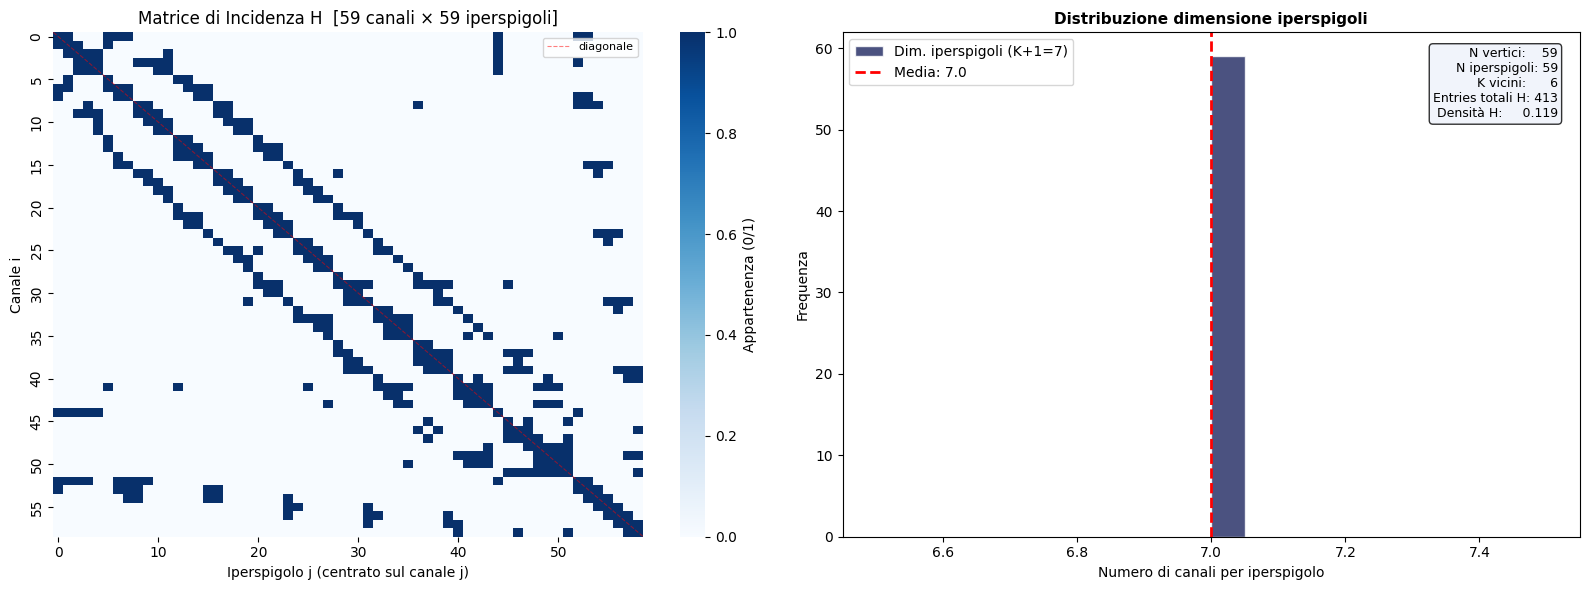

Saved: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg10_incidence_matrix.png


In [19]:
# ============================================================
# VIZ 1 — MATRICE DI INCIDENZA H  [59 × 59]
# Heatmap: righe = canali (vertici), colonne = iperspigoli
# H[i,j] = 1 se canale i appartiene all'iperspigolo j
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Sinistra: heatmap H ──────────────────────────────────────
H_np = np.zeros((N_CHANS, N_HYPER), dtype=np.float32)
hi = hyperedge_index.numpy()
for v, e in zip(hi[0], hi[1]):
    H_np[v, e] = 1.0

ax = axes[0]
sns.heatmap(H_np, cmap="Blues", linewidths=0, ax=ax,
            cbar_kws={"label": "Appartenenza (0/1)"},
            xticklabels=10, yticklabels=5)
ax.set_title(f"Matrice di Incidenza H  [{N_CHANS} canali × {N_HYPER} iperspigoli]")
ax.set_xlabel("Iperspigolo j (centrato sul canale j)")
ax.set_ylabel("Canale i")
# Annota diagonale (ogni canale è membro del proprio iperspigolo)
ax.plot([0, N_HYPER], [0, N_CHANS], "r--", lw=0.8, alpha=0.5, label="diagonale")
ax.legend(fontsize=8, loc="upper right")

# ── Destra: distribuzione dimensione iperspigoli ──────────────
ax2 = axes[1]
hyperedge_sizes = H_np.sum(axis=0)   # quanti canali per iperspigolo
vertex_degrees  = H_np.sum(axis=1)   # in quanti iperspigoli appare ogni canale

ax2.hist(hyperedge_sizes, bins=20, color="#1E2761", alpha=0.8, edgecolor="white",
         label=f"Dim. iperspigoli (K+1={K_HYPER+1})")
ax2.axvline(hyperedge_sizes.mean(), color="red", lw=2, ls="--",
            label=f"Media: {hyperedge_sizes.mean():.1f}")
ax2.set_title("Distribuzione dimensione iperspigoli", fontsize=11, fontweight="bold")
ax2.set_xlabel("Numero di canali per iperspigolo")
ax2.set_ylabel("Frequenza")
ax2.legend()

# Stats box
textstr = (f"N vertici:    {N_CHANS}\n"
           f"N iperspigoli: {N_HYPER}\n"
           f"K vicini:      {K_HYPER}\n"
           f"Entries totali H: {int(H_np.sum())}\n"
           f"Densità H:     {H_np.mean():.3f}")

ax2.text(0.97, 0.97, textstr, transform=ax2.transAxes, fontsize=9,
         verticalalignment="top", horizontalalignment="right",
         bbox=dict(boxstyle="round", facecolor="#EEF2FA", alpha=0.8))

plt.tight_layout()
fig_path = project_root / "figures" / "eeg10_incidence_matrix.png"
fig_path.parent.mkdir(exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

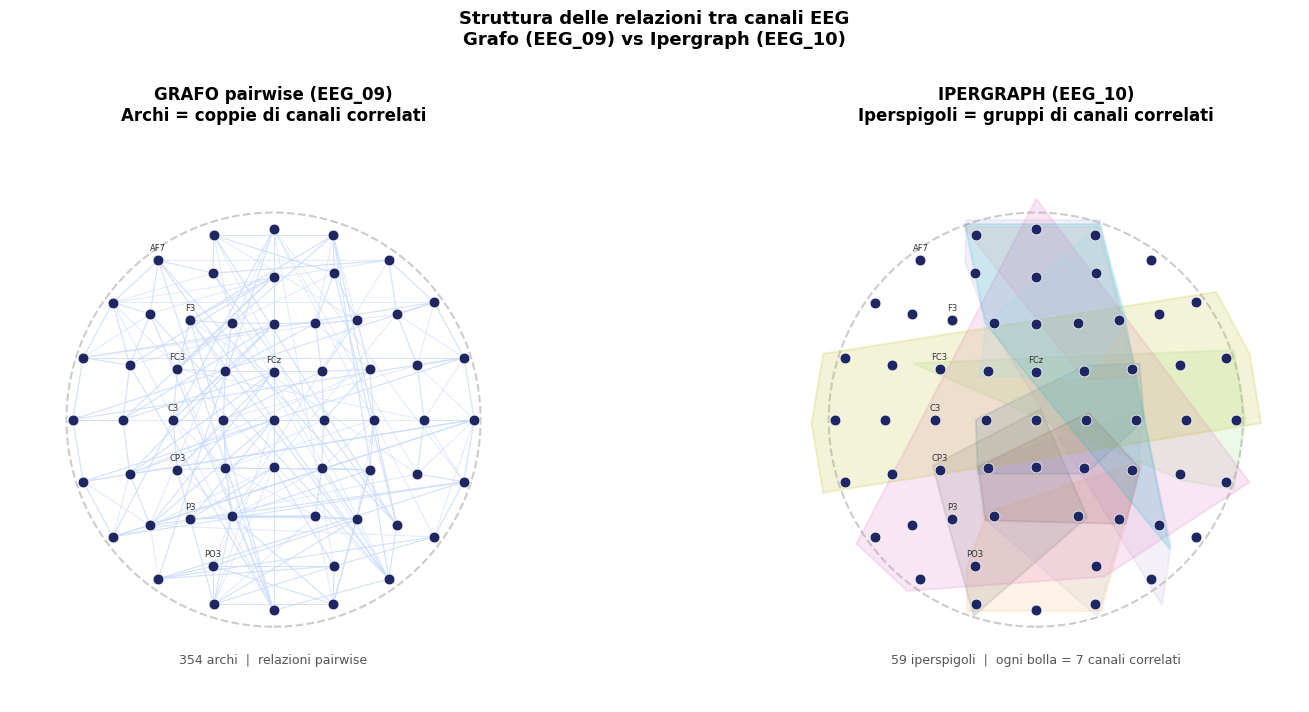

Saved: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg10_graph_vs_hypergraph.png


In [20]:
# ============================================================
# VIZ 2 — GRAFO (EEG_09) vs IPERGRAPH (EEG_10) — confronto
# Mostra visivamente la differenza strutturale:
#   - Grafo pairwise: archi tra 2 nodi
#   - Ipergraph: bolle che includono k+1 nodi
# ============================================================

import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from scipy.spatial import ConvexHull

def read_eloc_positions_2d(eloc_path, keep_names):
    """Legge posizioni 2D degli elettrodi dal file .locs."""
    pos = {}
    with open(eloc_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 4:
                continue
            try:
                theta  = float(parts[1])
                radius = float(parts[2])
                name   = parts[3]
            except ValueError:
                continue
            if name not in keep_names:
                continue
            th = math.radians(theta)
            pos[name] = np.array([radius * math.sin(th), radius * math.cos(th)])
    return pos

pos_dict = read_eloc_positions_2d(ELOC_PATH, keep_names)
# Ordina come keep_names per allineare con gli indici
pos_arr = np.array([pos_dict.get(n, np.array([0.0, 0.0])) for n in keep_names])  # [59, 2]

# Scegli un sottoinsieme per leggibilità (canali centrali + regione frontale)
SHOW_NODES = list(range(0, 59, 2))   # tutti i canali ogni 2

# Costruisci edge_index pairwise (k-NN da PCC) per confronto
from sklearn.neighbors import kneighbors_graph
pcc_dist = 1.0 - pcc_matrix   # distanza = 1 - |PCC|
np.fill_diagonal(pcc_dist, 0)
knn_matrix = kneighbors_graph(pcc_dist, K_HYPER, mode="connectivity",
                               metric="precomputed", include_self=False)
edge_pairs = np.array(knn_matrix.nonzero()).T   # [E, 2]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
COLORS_HE = plt.cm.tab20(np.linspace(0, 1, 12))   # colori iperspigoli mostrati

for ax_idx, (ax, title) in enumerate(zip(axes,
        ["GRAFO pairwise (EEG_09)\nArchi = coppie di canali correlati",
         "IPERGRAPH (EEG_10)\nIperspigoli = gruppi di canali correlati"])):


    ax.set_facecolor("#F8F9FC")
    ax.set_aspect("equal")

    # Disegna cerchio testa
    head = plt.Circle((0, 0), 0.55, fill=False, color="#CCCCCC", lw=1.5, ls="--")
    ax.add_patch(head)

    if ax_idx == 0:
        # ── Grafo pairwise ─────────────────────────────────
        # Disegna archi
        for (i, j) in edge_pairs:
            pi, pj = pos_arr[i], pos_arr[j]
            ax.plot([pi[0], pj[0]], [pi[1], pj[1]],
                    color="#CADCFC", lw=0.7, alpha=0.6, zorder=1)
        # Disegna nodi
        ax.scatter(pos_arr[:, 0], pos_arr[:, 1],
                   s=60, c="#1E2761", zorder=3, edgecolors="white", linewidths=0.5)
        # Label su alcuni
        for i in range(0, N_CHANS, 8):
            ax.annotate(keep_names[i], pos_arr[i],
                        fontsize=6, ha="center", va="bottom",
                        xytext=(0, 5), textcoords="offset points", color="#333333")

        ax.text(0, -0.65, f"{len(edge_pairs)} archi  |  relazioni pairwise",
                ha="center", fontsize=9, color="#555555")

    else:
        # ── Ipergraph ──────────────────────────────────────
        # Mostra i primi 12 iperspigoli con hull colorato
        H_np_local = np.zeros((N_CHANS, N_HYPER), dtype=bool)
        hi_np = hyperedge_index.numpy()
        for v, e in zip(hi_np[0], hi_np[1]):
            H_np_local[v, e] = True

        n_show = 12
        shown_edges = np.random.RandomState(0).choice(N_HYPER, n_show, replace=False)

        for color_idx, e_idx in enumerate(shown_edges):
            members = np.where(H_np_local[:, e_idx])[0]
            pts = pos_arr[members]

            if len(pts) >= 3:
                try:
                    hull = ConvexHull(pts)
                    hull_pts = pts[hull.vertices]
                    # Espandi leggermente il hull
                    centroid = hull_pts.mean(axis=0)
                    expanded = centroid + 1.12 * (hull_pts - centroid)
                    poly = mpatches.Polygon(expanded, closed=True,
                                            alpha=0.18,
                                            facecolor=COLORS_HE[color_idx],
                                            edgecolor=COLORS_HE[color_idx],
                                            linewidth=1.5,
                                            zorder=1)
                    ax.add_patch(poly)
                except Exception:
                    pass

        # Disegna nodi sopra
        ax.scatter(pos_arr[:, 0], pos_arr[:, 1],
                   s=60, c="#1E2761", zorder=3, edgecolors="white", linewidths=0.5)
        for i in range(0, N_CHANS, 8):
            ax.annotate(keep_names[i], pos_arr[i],
                        fontsize=6, ha="center", va="bottom",
                        xytext=(0, 5), textcoords="offset points", color="#333333")

        ax.text(0, -0.65,
                f"{N_HYPER} iperspigoli  |  ogni bolla = {K_HYPER+1} canali correlati",
                ha="center", fontsize=9, color="#555555")

    ax.set_title(title, fontsize=12, fontweight="bold", pad=12)
    ax.set_xlim(-0.7, 0.7)
    ax.set_ylim(-0.75, 0.75)
    ax.axis("off")

plt.suptitle("Struttura delle relazioni tra canali EEG\n"
             "Grafo (EEG_09) vs Ipergraph (EEG_10)",
             fontsize=13, fontweight="bold", y=1.01)

plt.tight_layout()
fig_path = project_root / "figures" / "eeg10_graph_vs_hypergraph.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

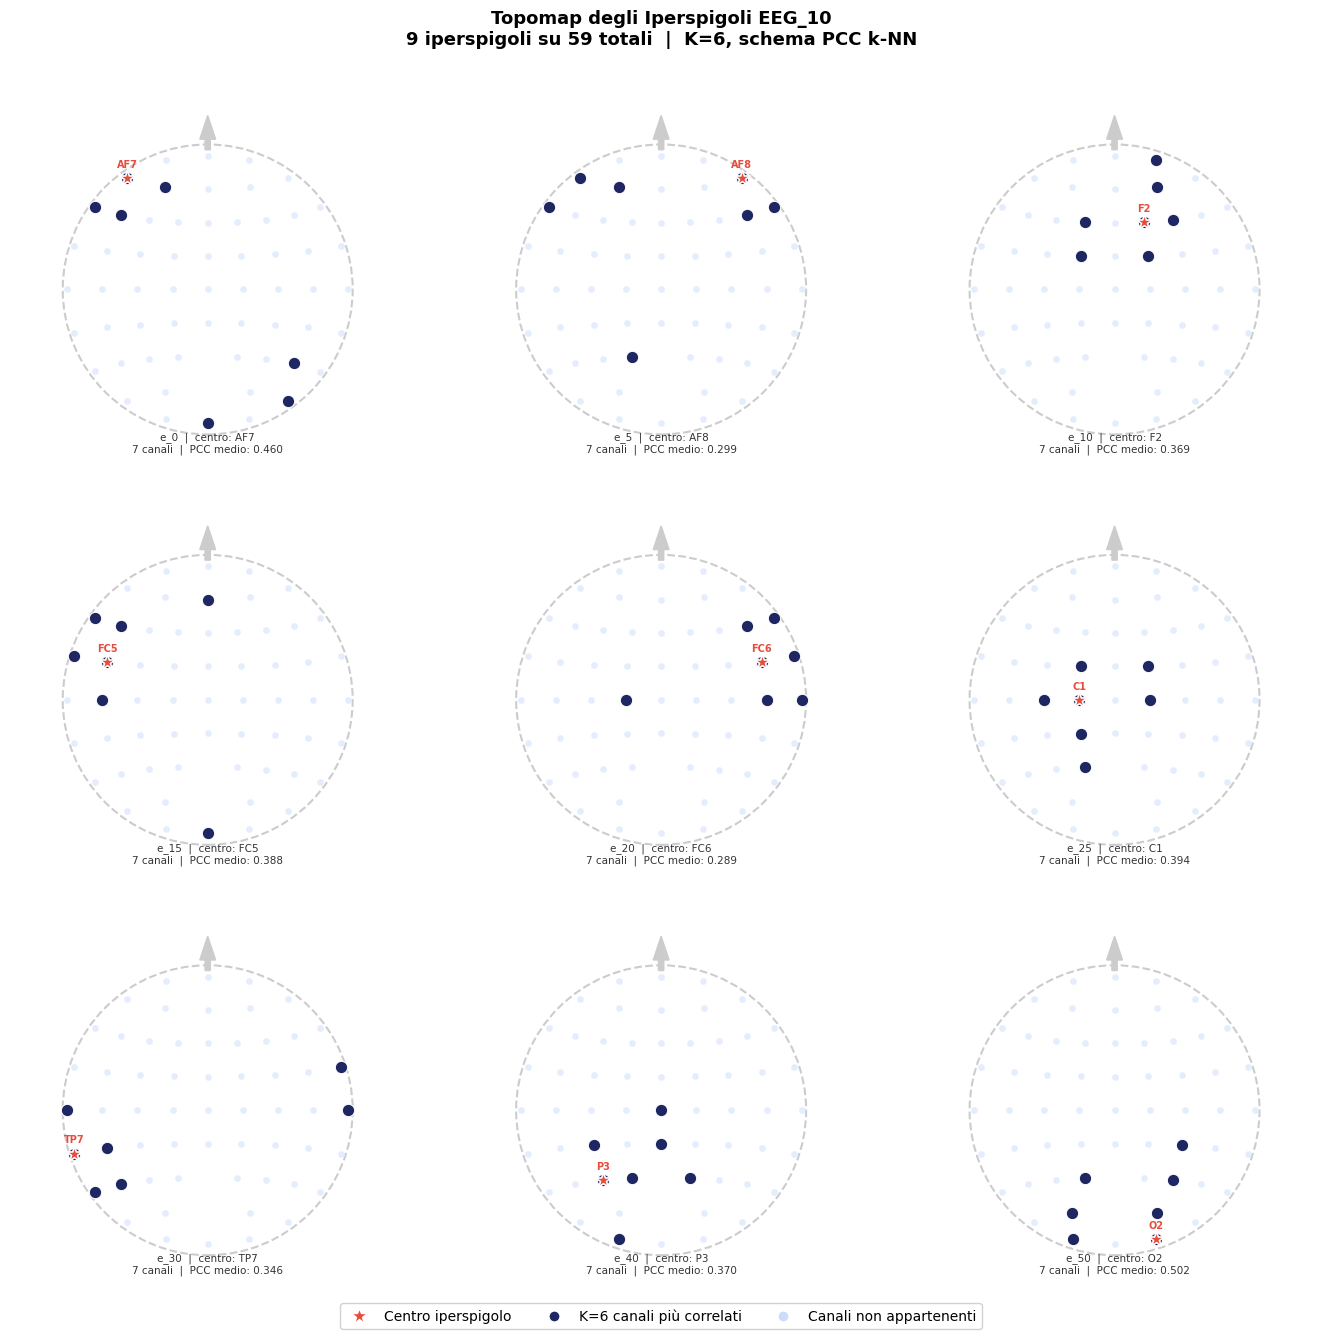

Saved: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg10_hyperedge_topomaps.png

Lettura: ogni plot mostra un iperspigolo e_i
  ★ rosso = canale centrale (i)
  ● blu scuro = K=6 canali più correlati per |PCC|
  ● azzurro = canali non appartenenti all'iperspigolo


In [21]:
# ============================================================
# VIZ 3 — TOPOMAP DEGLI IPERSPIGOLI
# Mostra i primi 9 iperspigoli come topomaps:
# ogni plot evidenzia i canali che appartengono a quell'iperspigolo
# ============================================================

import matplotlib.colors as mcolors

# Scegli 9 iperspigoli rappresentativi
# Prendi quelli centrati su regioni cerebrali diverse
SHOW_HE = [0, 5, 10, 15, 20, 25, 30, 40, 50]
n_show  = len(SHOW_HE)

fig, axes = plt.subplots(3, 3, figsize=(14, 13))
axes = axes.flatten()

H_np_show = np.zeros((N_CHANS, N_HYPER), dtype=bool)
hi_np = hyperedge_index.numpy()
for v, e in zip(hi_np[0], hi_np[1]):
    H_np_show[v, e] = True

for plot_idx, he_idx in enumerate(SHOW_HE):
    ax = axes[plot_idx]
    ax.set_facecolor("#F8F9FC")
    ax.set_aspect("equal")

    members = np.where(H_np_show[:, he_idx])[0]
    center  = he_idx   # il centro dell'iperspigolo è il canale he_idx

    # Testa
    head = plt.Circle((0, 0), 0.55, fill=False, color="#CCCCCC", lw=1.5, ls="--")
    nose = mpatches.FancyArrow(0, 0.53, 0, 0.04, width=0.02, color="#CCCCCC")
    ax.add_patch(head)
    ax.add_patch(nose)

    # Canali non nell'iperspigolo
    non_members = [i for i in range(N_CHANS) if i not in members]
    if non_members:
        nm_pos = pos_arr[non_members]
        ax.scatter(nm_pos[:, 0], nm_pos[:, 1],
                   s=25, c="#CADCFC", zorder=2, edgecolors="white", lw=0.3, alpha=0.5)

    # Canali nell'iperspigolo — evidenziati
    m_pos = pos_arr[members]
    sc = ax.scatter(m_pos[:, 0], m_pos[:, 1],
                    s=80, c="#1E2761", zorder=4, edgecolors="white", lw=0.8)

    # Centro dell'iperspigolo (canale he_idx) — evidenziato
    if center < N_CHANS:
        cp = pos_arr[center]
        ax.scatter([cp[0]], [cp[1]],
                   s=140, c="#E74C3C", zorder=5, edgecolors="white", lw=1.2,
                   marker="*")
        ax.annotate(keep_names[center], cp,
                    fontsize=7, ha="center", va="bottom",
                    xytext=(0, 6), textcoords="offset points",
                    color="#E74C3C", fontweight="bold")

    # PCC medio dei membri rispetto al centro
    if center < N_CHANS:
        mean_pcc = pcc_matrix[center, members].mean()
        ax.text(0, -0.62,
                f"e_{he_idx}  |  centro: {keep_names[center]}\n"                f"{len(members)} canali  |  PCC medio: {mean_pcc:.3f}",
                ha="center", fontsize=7.5, color="#333333",
                multialignment="center")
    else:
        ax.text(0, -0.62, f"e_{he_idx}  |  {len(members)} canali",
                ha="center", fontsize=8, color="#333333")

    ax.set_xlim(-0.75, 0.75)
    ax.set_ylim(-0.75, 0.75)
    ax.axis("off")

# Legenda
from matplotlib.lines import Line2D
legend_els = [
    Line2D([0], [0], marker="*", color="w", markerfacecolor="#E74C3C",
           markersize=12, label="Centro iperspigolo"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#1E2761",
           markersize=8, label=f"K={K_HYPER} canali più correlati"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#CADCFC",
           markersize=8, label="Canali non appartenenti"),
]
fig.legend(handles=legend_els, loc="lower center", ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, -0.01),
           framealpha=0.9)

plt.suptitle(f"Topomap degli Iperspigoli EEG_10\n"             f"9 iperspigoli su {N_HYPER} totali  |  K={K_HYPER}, schema PCC k-NN",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
fig_path = project_root / "figures" / "eeg10_hyperedge_topomaps.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")
print(f"\nLettura: ogni plot mostra un iperspigolo e_i")
print(f"  ★ rosso = canale centrale (i)")
print(f"  ● blu scuro = K={K_HYPER} canali più correlati per |PCC|")
print(f"  ● azzurro = canali non appartenenti all'iperspigolo")

In [22]:
# ============================================================
# HYPERGRAPHDATA + DATASET
#
# Fix 1 (CORRETTO) — hyperedge_index PER-TRIAL
#   Ogni trial ha il proprio grafo calcolato dal suo segnale EEG.
#   ~38K grafi distinti, uno per trial (CLAUDE.md §8.1).
#   pcc_to_hyperedge_index_trial(x_np, k) chiamata in _preload_all().
#
# Fix 2 — preload in RAM
#   Tutti i tensori x + hyperedge_index letti da H5 una volta sola.
#   Durante il training: zero I/O disco per ogni batch.
#   RAM richiesta: x ≈ 3.4 GB + he ≈ 0.7 GB ≈ 4.1 GB totali
# ============================================================


class HypergraphData(Data):
    """
    Subclasse Data PyG con batching corretto per hyperedge_index.
    row 0 (vertex):    incrementa di num_nodes
    row 1 (hyperedge): incrementa di num_hyperedges
    """
    def __inc__(self, key, value, *args, **kwargs):
        if key == "hyperedge_index":
            return torch.tensor([[self.num_nodes], [int(self.num_hyperedges)]])
        return super().__inc__(key, value, *args, **kwargs)


class EEGHypergraphDataset(Dataset):
    """
    Dataset PyG per modelli ipergraph — GRAPH CLASSIFICATION PER-TRIAL.

    Ogni trial ha il proprio hyperedge_index calcolato dalla sua matrice PCC
    (CLAUDE.md §8.1: ~38K grafi distinti, mai un grafo statico condiviso).

    Fix 2: preload=True — carica tutti x e hyperedge_index in RAM al __init__.
    """

    def __init__(self, records, keep_idx, labelid2cluster,
                 n_hyper,            # numero iperspigoli (= N_CHANS = 59)
                 k=K_HYPER,
                 mean=None, std=None,
                 preload=True):      # Fix 2: precarica in RAM
        self.records         = records
        self.keep_idx        = keep_idx
        self.labelid2cluster = labelid2cluster
        self.n_hyper         = n_hyper
        self.k               = k
        self.mean            = mean
        self.std             = std
        self.x_cache         = None
        self._he             = None

        if mean is None:
            self._compute_stats()

        if preload:
            self._preload_all()

    def _compute_stats(self, seed=42):
        rng  = np.random.RandomState(seed)
        n    = min(500, len(self.records))
        idxs = rng.choice(len(self.records), n, replace=False)
        paths_map = defaultdict(list)
        for idx in idxs:
            r = self.records[idx]
            paths_map[r["path_h5"]].append(int(r["epoch_idx"]))
        buf = []
        print(f"Calcolo stats su {n} campioni...")
        for path, epoch_idxs in tqdm(paths_map.items(), desc="Stats H5", leave=False):
            with h5py.File(path, "r") as f:
                for e_idx in epoch_idxs:
                    buf.append(f["data"][e_idx][self.keep_idx, :].astype(np.float32))
        buf = np.stack(buf)
        self.mean = torch.tensor(buf.mean(axis=(0, 2), keepdims=True).squeeze(0), dtype=torch.float32)
        self.std  = torch.tensor(buf.std(axis=(0, 2),  keepdims=True).squeeze(0).clip(1e-6), dtype=torch.float32)
        print(f"Stats OK | mean: [{self.mean.min():.3f}, {self.mean.max():.3f}]")

    def _preload_all(self):
        """Fix 2: carica tutti i trial in RAM + calcola hyperedge PER-TRIAL."""
        print(f"Preload {len(self.records)} trial in RAM (x + hyperedges per-trial)...")
        paths_map = defaultdict(list)
        for i, r in enumerate(self.records):
            paths_map[r["path_h5"]].append((i, int(r["epoch_idx"])))

        tmp_x  = [None] * len(self.records)
        tmp_he = [None] * len(self.records)
        for path, items in tqdm(paths_map.items(), desc="Preload H5", leave=False):
            with h5py.File(path, "r") as f:
                for idx, e_idx in items:
                    x_np       = f["data"][e_idx][self.keep_idx, :].astype(np.float32)
                    tmp_x[idx]  = (torch.tensor(x_np) - self.mean) / self.std
                    tmp_he[idx] = pcc_to_hyperedge_index_trial(x_np, k=self.k)  # per-trial!
        self.x_cache = tmp_x
        self._he     = tmp_he
        ram_gb = sum(x.element_size() * x.nelement() for x in self.x_cache) / 1e9
        print(f"Preload OK | RAM x: {ram_gb:.2f} GB | hyperedges per-trial: {len(self._he)}")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        if self.x_cache is not None:
            x  = self.x_cache[idx]          # Fix 2: da RAM
            he = self._he[idx]              # per-trial!
        else:
            r = self.records[idx]
            with h5py.File(r["path_h5"], "r") as f:
                x_np = f["data"][int(r["epoch_idx"])][self.keep_idx, :].astype(np.float32)
            x  = (torch.tensor(x_np) - self.mean) / self.std
            he = pcc_to_hyperedge_index_trial(x_np, k=self.k)  # per-trial fallback

        label = self.labelid2cluster[int(self.records[idx]["label_idx"])]
        return HypergraphData(
            x               = x,
            hyperedge_index = he,              # per-trial (non più globale)
            num_hyperedges  = torch.tensor(self.n_hyper, dtype=torch.long),
            y               = torch.tensor(label, dtype=torch.long),
        )


def make_hypergraph_splits(meta_df, labelid2cluster, subj_train, subj_val, subj_test,
                            n_hyper, k=K_HYPER, preload=True):
    """Split subject-independent — hyperedge_index PER-TRIAL (CLAUDE.md §8.1)."""
    def to_records(df_sub):
        return df_sub[["path_h5", "epoch_idx", "label_idx", "subject_id"]].to_dict("records")

    train_ids = [str(i).zfill(2) for i in subj_train]
    val_ids   = [str(i).zfill(2) for i in subj_val]
    test_ids  = [str(i).zfill(2) for i in subj_test]

    df_tr = meta_df[meta_df["subject_id"].isin(train_ids)]
    df_va = meta_df[meta_df["subject_id"].isin(val_ids)]
    df_te = meta_df[meta_df["subject_id"].isin(test_ids)]

    print("=== Costruzione split ===")
    ds_tr = EEGHypergraphDataset(to_records(df_tr), keep_idx, labelid2cluster,
                                  n_hyper, k=k, preload=preload)
    ds_va = EEGHypergraphDataset(to_records(df_va), keep_idx, labelid2cluster,
                                  n_hyper, k=k,
                                  mean=ds_tr.mean, std=ds_tr.std, preload=preload)
    ds_te = EEGHypergraphDataset(to_records(df_te), keep_idx, labelid2cluster,
                                  n_hyper, k=k,
                                  mean=ds_tr.mean, std=ds_tr.std, preload=preload)

    print(f"Split OK: train={len(ds_tr)}, val={len(ds_va)}, test={len(ds_te)}")
    return ds_tr, ds_va, ds_te


print("EEGHypergraphDataset (per-trial hyperedges) pronto")
print(f"Ogni trial ha il proprio hyperedge_index PCC-based (CLAUDE.md §8.1)")


EEGHypergraphDataset (Fix1+Fix2) pronto
Fix1: hyperedge_index globale — nessun PCC per-trial
Fix2: preload=True — tutti i trial in RAM prima del training


In [23]:
# ============================================================
# MODELLI HYPERGRAPH
#
# 1. HGNN_2L      — static hyperedges (PCC k-NN)
#                   Feng et al. 2019 — HGNN (AAAI)
#
# 2. HGNN_2L_DYN  — layer 1: static, layer 2: dynamic
#                   Struttura aggiornata nel feature space
#                   Ispirazione: Li et al. 2025 — DHSLP
#
# 3. HGNN_ATT_2L  — static + attention sugli iperspigoli
#                   use_attention=True in HypergraphConv
#                   Ispirazione: Chien et al. 2022 — AllSet
#
# TemporalEncoder — IDENTICO a EEG_08/09 (1D CNN per canale)
# ============================================================


# ── Temporal Encoder (invariato da EEG_08) ──────────────────
class TemporalEncoder(nn.Module):
    """
    1D CNN per-nodo con pesi condivisi tra tutti i canali.
    Input:  (N_nodes_total, N_TIMES)
    Output: (N_nodes_total, out_dim)
    """
    def __init__(self, n_times=N_TIMES, out_dim=NODE_EMB_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=25, stride=2, padding=12),
            nn.BatchNorm1d(32), nn.ELU(),
            nn.Conv1d(32, 64, kernel_size=10, stride=2, padding=5),
            nn.BatchNorm1d(64), nn.ELU(),
            nn.AdaptiveAvgPool1d(4),
            nn.Flatten(),
            nn.Linear(64 * 4, out_dim),
            nn.ELU(),
        )

    def forward(self, x):
        return self.net(x.unsqueeze(1))   # (N, 1, T) → (N, out_dim)


# ── Costruzione dinamica degli iperspigoli ──────────────────
def build_dynamic_hyperedge_index(x, batch, k=6):
    """
    Costruisce hyperedge_index dinamicamente dal feature space corrente.
    Ispirazione diretta: Li et al. 2025 (DHSLP) — distanza-based hyperedge.

    Per ogni nodo i in ogni grafo del batch:
        e_i = {i} ∪ {top-k nodi con cosine similarity più alta}

    Args:
        x:     [N_total, D]  — node features post primo layer
        batch: [N_total]     — batch assignment PyG
        k:     int           — numero di vicini

    Returns:
        hyperedge_index: [2, E] LongTensor (già offsettato per batch)
    """
    num_graphs   = int(batch.max().item()) + 1
    vertex_list, edge_list = [], []
    edge_offset = 0
    node_offset = 0

    for g in range(num_graphs):
        mask = (batch == g)
        x_g  = x[mask]   # [N_g, D]
        N_g  = x_g.shape[0]

        # Cosine similarity [N_g, N_g]
        x_norm = F.normalize(x_g.detach(), p=2, dim=1)
        sim    = x_norm @ x_norm.T

        # Top-k più simili per ogni nodo (include se stesso)
        _, topk = torch.topk(sim, k=min(k + 1, N_g), dim=1)  # [N_g, k+1]

        for i in range(N_g):
            for j in topk[i].tolist():
                vertex_list.append(node_offset + j)
                edge_list.append(edge_offset + i)

        node_offset += N_g
        edge_offset += N_g  # N_g iperspigoli per grafo

    return torch.tensor([vertex_list, edge_list], dtype=torch.long, device=x.device)


# ── HGNN_2L — iperspigoli statici ────────────────────────────
class HGNN_2L(nn.Module):
    """
    2 layer HypergraphConv con iperspigoli statici (PCC k-NN).
    Baseline hypergraph — confronto diretto con GAT_2L (EEG_09).
    Ref: Feng et al. 2019 — HGNN (AAAI)
    """
    def __init__(self, n_classes=N_CLASSES, n_times=N_TIMES,
                 node_emb_dim=NODE_EMB_DIM, hidden=HIDDEN_DIM, dropout=DROPOUT):
        super().__init__()
        self.temporal_enc = TemporalEncoder(n_times, node_emb_dim)
        self.conv1 = HypergraphConv(node_emb_dim, hidden)
        self.bn1   = nn.BatchNorm1d(hidden)
        self.conv2 = HypergraphConv(hidden, hidden)
        self.bn2   = nn.BatchNorm1d(hidden)
        self.drop  = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, n_classes),
        )

    def forward(self, data):
        x  = data.x
        he = data.hyperedge_index

        x = self.temporal_enc(x)

        x = F.elu(self.bn1(self.conv1(x, he)))
        x = self.drop(x)
        x = F.elu(self.bn2(self.conv2(x, he)))

        x = global_mean_pool(x, data.batch)
        return self.classifier(x)


# ── HGNN_2L_DYN — iperspigoli dinamici al layer 2 ────────────
class HGNN_2L_DYN(nn.Module):
    """
    Layer 1: HypergraphConv con struttura statica (PCC).
    Layer 2: HypergraphConv con struttura dinamica (feature cosine sim).
    Il secondo layer vede relazioni aggiornate al feature space corrente.
    Ispirazione: Li et al. 2025 — DHSLP (dynamic structure learning).
    """
    def __init__(self, n_classes=N_CLASSES, n_times=N_TIMES,
                 node_emb_dim=NODE_EMB_DIM, hidden=HIDDEN_DIM,
                 k=K_HYPER, dropout=DROPOUT):
        super().__init__()
        self.k = k
        self.temporal_enc = TemporalEncoder(n_times, node_emb_dim)
        self.conv1 = HypergraphConv(node_emb_dim, hidden)
        self.bn1   = nn.BatchNorm1d(hidden)
        self.conv2 = HypergraphConv(hidden, hidden)
        self.bn2   = nn.BatchNorm1d(hidden)
        self.drop  = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, n_classes),
        )

    def forward(self, data):
        x        = data.x
        he_static = data.hyperedge_index

        x = self.temporal_enc(x)

        # Layer 1: struttura statica (PCC k-NN)
        x = F.elu(self.bn1(self.conv1(x, he_static)))
        x = self.drop(x)

        # Aggiorna struttura ipergraph nel feature space corrente
        he_dyn = build_dynamic_hyperedge_index(x, data.batch, k=self.k)

        # Layer 2: struttura dinamica (cosine sim features)
        x = F.elu(self.bn2(self.conv2(x, he_dyn)))

        x = global_mean_pool(x, data.batch)
        return self.classifier(x)


# ── HGNN_ATT_2L — attention sugli iperspigoli ────────────────
def hyperedge_mean_attr(x, hyperedge_index, num_edges):
    """
    Calcola attributi degli iperspigoli come mean-pool dei nodi membri.
    Richiesto da HypergraphConv(use_attention=True).

    Args:
        x:               [N_nodes_total, F]
        hyperedge_index: [2, E]  row0=vertex, row1=hyperedge
        num_edges:       int — numero totale iperspigoli nel batch

    Returns:
        hyperedge_attr: [num_edges, F]
    """
    node_idx = hyperedge_index[0]   # quali nodi
    edge_idx = hyperedge_index[1]   # a quale iperspigolo appartengono
    F_dim    = x.shape[1]
    he_attr  = torch.zeros(num_edges, F_dim, device=x.device, dtype=x.dtype)
    he_attr.scatter_add_(0, edge_idx.unsqueeze(1).expand(-1, F_dim), x[node_idx])
    count = torch.zeros(num_edges, device=x.device, dtype=x.dtype)
    count.scatter_add_(0, edge_idx, torch.ones(edge_idx.shape[0], device=x.device, dtype=x.dtype))
    return he_attr / count.unsqueeze(1).clamp(min=1)


class HGNN_ATT_2L(nn.Module):
    """
    2 layer HypergraphConv con attention (use_attention=True).
    Il meccanismo di attenzione pesa i contributi dei nodi
    dentro ogni iperspigolo — simile a GAT ma su hyperedge.
    hyperedge_attr calcolato come mean-pool dei nodi per iperspigolo.
    Ispirazione: Chien et al. 2022 — AllSet (ICLR).
    """
    def __init__(self, n_classes=N_CLASSES, n_times=N_TIMES,
                 node_emb_dim=NODE_EMB_DIM, hidden=HIDDEN_DIM,
                 heads=HGNN_HEADS, dropout=DROPOUT):
        super().__init__()
        self.temporal_enc = TemporalEncoder(n_times, node_emb_dim)
        self.conv1 = HypergraphConv(node_emb_dim, hidden,
                                    use_attention=True, heads=heads,
                                    concat=False, dropout=dropout)
        self.bn1   = nn.BatchNorm1d(hidden)
        self.conv2 = HypergraphConv(hidden, hidden,
                                    use_attention=True, heads=heads,
                                    concat=False, dropout=dropout)
        self.bn2   = nn.BatchNorm1d(hidden)
        self.drop  = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, n_classes),
        )

    def forward(self, data):
        x   = data.x
        he  = data.hyperedge_index
        n_e = int(data.num_hyperedges.sum().item())

        x = self.temporal_enc(x)

        he_attr1 = hyperedge_mean_attr(x, he, n_e)
        x = F.elu(self.bn1(self.conv1(x, he, hyperedge_attr=he_attr1)))
        x = self.drop(x)

        he_attr2 = hyperedge_mean_attr(x, he, n_e)
        x = F.elu(self.bn2(self.conv2(x, he, hyperedge_attr=he_attr2)))

        x = global_mean_pool(x, data.batch)
        return self.classifier(x)


# Registro modelli
HGNN_MODELS = {
    "HGNN_2L":     {"cls": HGNN_2L,     "desc": "Static hyperedges (PCC k-NN)"},
    "HGNN_2L_DYN": {"cls": HGNN_2L_DYN, "desc": "Dynamic hyperedges (layer 2)"},
    "HGNN_ATT_2L": {"cls": HGNN_ATT_2L, "desc": "Static + attention on hyperedges"},
}

total_params = sum(p.numel() for p in HGNN_2L().parameters())
print(f"Parametri HGNN_2L: {total_params:,}")
print(f"Modelli da trainare: {list(HGNN_MODELS.keys())}")

Parametri HGNN_2L: 48,804
Modelli da trainare: ['HGNN_2L', 'HGNN_2L_DYN', 'HGNN_ATT_2L']


In [24]:
# ============================================================
# CLASS WEIGHTS + SPLIT DATASET
# Usa Fix1 (hyperedge globale) + Fix2 (preload RAM)
# ============================================================

ds_train, ds_val, ds_test = make_hypergraph_splits(
    meta, labelid2cluster,
    SUBJ_TRAIN, SUBJ_VAL, SUBJ_TEST,
    n_hyper = N_HYPER,
    preload = True,    # preload x + hyperedges per-trial in RAM
)

# Salva stats normalizzazione prima che Fix3 possa sostituire ds_train
train_mean, train_std = ds_train.mean, ds_train.std

# Class weights inversi alla frequenza
all_labels   = [labelid2cluster[int(r["label_idx"])] for r in ds_train.records]
counts       = torch.bincount(torch.tensor(all_labels), minlength=N_CLASSES).float()
class_weights = (1.0 / counts.clamp(min=1))
class_weights = (class_weights / class_weights.sum() * N_CLASSES).to(device)

print("\nClass weights (training set):")
for i, (c, w) in enumerate(zip(cluster_names, class_weights.cpu())):
    print(f"  classe {i} ({c}): {int(counts[i])} trial -> weight={w:.3f}")


=== Costruzione split ===
Calcolo stats su 500 campioni...


Stats H5:   0%|          | 0/215 [00:00<?, ?it/s]

Stats OK | mean: [-0.077, 0.075]
Preload 26166 trial in RAM...


Preload H5:   0%|          | 0/241 [00:00<?, ?it/s]

Preload OK | RAM: 2.37 GB
Preload 5500 trial in RAM...


Preload H5:   0%|          | 0/50 [00:00<?, ?it/s]

Preload OK | RAM: 0.50 GB
Preload 7260 trial in RAM...


Preload H5:   0%|          | 0/66 [00:00<?, ?it/s]

Preload OK | RAM: 0.66 GB
Split OK: train=26166, val=5500, test=7260

Class weights (training set):
  classe 0 (0): 4290 trial -> weight=1.361
  classe 1 (1): 6412 trial -> weight=0.911
  classe 2 (2): 4992 trial -> weight=1.170
  classe 3 (3): 10472 trial -> weight=0.558


In [25]:
# ============================================================
# FIX 3 — PRE-BUILT DATASET SU DISCO (OPZIONALE)
#
# Prima run: costruisce dataset_hgnn_k6.pt (~3.7 GB, ~15min)
# Run successive: carica da disco in ~30sec, zero preprocessing.
#
# Vantaggio rispetto a Fix1+Fix2:
#   - Fix1+Fix2: preload RAM ogni run (~2min per 38k trial da H5)
#   - Fix3: load da .pt una volta, poi accesso O(1) indicizzato
#
# Imposta USE_PREBUILT=True per attivare.
# ============================================================

USE_PREBUILT   = True
PREBUILT_PATH  = interim_dir / "graphs" / "dataset_hgnn_k6.pt"
FORCE_REBUILD  = True   # rebuild necessario: .pt precedente usava he globale


def build_hgnn_pt(meta_df, keep_idx, labelid2cluster,
                  n_hyper, k, mean, std, save_path):
    """
    Pre-costruisce lista HypergraphData e salva su disco.
    x normalizzato, hyperedge_index PER-TRIAL (CLAUDE.md §8.1).
    Salva anche subj per split.
    """
    records  = meta_df[["path_h5", "epoch_idx", "label_idx", "subject_id"]].to_dict("records")
    dataset  = []
    paths_map = defaultdict(list)
    for i, r in enumerate(records):
        paths_map[r["path_h5"]].append((i, int(r["epoch_idx"]),
                                         int(r["label_idx"]),
                                         str(r["subject_id"])))
    tmp = [None] * len(records)
    print(f"Building {len(records)} HypergraphData objects...")
    for path, items in tqdm(paths_map.items(), desc="Build H5", leave=False):
        with h5py.File(path, "r") as f:
            for idx, e_idx, label_idx, subj_str in items:
                x_np = f["data"][e_idx][keep_idx, :].astype(np.float32)
                x    = (torch.tensor(x_np) - mean) / std
                he   = pcc_to_hyperedge_index_trial(x_np, k=k)  # per-trial!
                try:
                    subj = int(subj_str)
                except ValueError:
                    continue  # skip ignore_43 e simili
                label = labelid2cluster[label_idx]
                tmp[idx] = HypergraphData(
                    x               = x,
                    hyperedge_index = he,              # per-trial (non globale)
                    num_hyperedges  = torch.tensor(n_hyper, dtype=torch.long),
                    y               = torch.tensor(label, dtype=torch.long),
                    subj            = torch.tensor(subj,  dtype=torch.long),
                )
    save_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(tmp, save_path)
    sz = save_path.stat().st_size / 1e9
    print(f"Salvato: {save_path}  ({sz:.2f} GB)")
    return tmp


class PrebuiltHypergraphDataset(Dataset):
    """Dataset minimo che wrappa lista pre-costruita da .pt."""
    def __init__(self, data_list):
        self.data_list = data_list
    def __len__(self):
        return len(self.data_list)
    def __getitem__(self, idx):
        return self.data_list[idx]


if USE_PREBUILT:
    if not PREBUILT_PATH.exists() or FORCE_REBUILD:
        print("Pre-built non trovato — costruzione in corso...")
        all_data = build_hgnn_pt(
            meta, keep_idx, labelid2cluster, N_HYPER,
            ds_train.mean, ds_train.std,
            PREBUILT_PATH,
        )
    else:
        print(f"Carico pre-built da: {PREBUILT_PATH}")
        all_data = torch.load(PREBUILT_PATH, weights_only=False)
        print(f"  {len(all_data)} oggetti caricati")

    # Ricostruisci split dal campo subj
    subj_tensor = torch.tensor([d.subj.item() for d in all_data])
    train_set = set(SUBJ_TRAIN)
    val_set   = set(SUBJ_VAL)
    test_set  = set(SUBJ_TEST)

    idx_tr = [i for i, s in enumerate(subj_tensor.tolist()) if s in train_set]
    idx_va = [i for i, s in enumerate(subj_tensor.tolist()) if s in val_set]
    idx_te = [i for i, s in enumerate(subj_tensor.tolist()) if s in test_set]

    ds_train = PrebuiltHypergraphDataset([all_data[i] for i in idx_tr])
    ds_val   = PrebuiltHypergraphDataset([all_data[i] for i in idx_va])
    ds_test  = PrebuiltHypergraphDataset([all_data[i] for i in idx_te])

    print(f"Split (pre-built): train={len(ds_train)}, val={len(ds_val)}, test={len(ds_test)}")
    print("FIX 3 attivo — I/O H5 azzerato, epoch speed massima")
else:
    print("FIX 3 disattivato — uso Fix1+Fix2 da RAM")


Carico pre-built da: /home/daniele_u/miralis-hypergraph-imagined-speech/data/interim/graphs/dataset_hgnn_k6.pt
  38926 oggetti caricati
Split (pre-built): train=26166, val=5500, test=7260
FIX 3 attivo — I/O H5 azzerato, epoch speed massima


In [26]:
# ============================================================
# SANITY CHECK — forward pass
# ============================================================

print("=== Sanity check forward pass ===")

# Campiona 4 elementi direttamente da ds_train (già pre-built o preloaded)
batch_sample = next(iter(PyGDataLoader(ds_train, batch_size=4, shuffle=True)))

print(f"Batch x:                {batch_sample.x.shape}      # (4x59, 384)")
print(f"Batch hyperedge_index:  {batch_sample.hyperedge_index.shape}")
print(f"  vertex range:         [0, {batch_sample.hyperedge_index[0].max().item()}]  (atteso: {4*N_CHANS-1})")
print(f"  hyperedge range:      [0, {batch_sample.hyperedge_index[1].max().item()}]  (atteso: {4*N_HYPER-1})")
print(f"Batch y:                {batch_sample.y}")

for name, cfg in HGNN_MODELS.items():
    m = cfg["cls"]().to(device)
    m.eval()
    with torch.no_grad():
        logits = m(batch_sample.to(device))
        print(f"  {name}: logits={logits.shape} OK")
    m.to("cpu")

print("\nSanity check OK")


=== Sanity check forward pass ===
Batch x:                torch.Size([236, 384])      # (4x59, 384)
Batch hyperedge_index:  torch.Size([2, 1652])
  vertex range:         [0, 235]  (atteso: 235)
  hyperedge range:      [0, 235]  (atteso: 235)
Batch y:                tensor([2, 0, 2, 3])
  HGNN_2L: logits=torch.Size([4, 4]) OK
  HGNN_2L_DYN: logits=torch.Size([4, 4]) OK
  HGNN_ATT_2L: logits=torch.Size([4, 4]) OK

Sanity check OK


In [27]:
# ============================================================
# FUNZIONE DI TRAINING (standard, senza adversarial)
# Identica struttura a EEG_09 train_gat — adattata per hypergraph
# ============================================================

def train_hgnn(model, ds_train, ds_val, save_path, tb_dir,
               n_epochs=MAX_EPOCHS, patience=PATIENCE,
               lr=LR, weight_decay=WEIGHT_DECAY, batch_size=BATCH_SIZE,
               class_weights=None, resume=RESUME,
               wandb_run=None):
    """
    Training con early stopping su val_bacc.
    Class weights per gestire sbilanciamento concr4.
    CosineAnnealingLR + gradient clipping.
    wandb_run: oggetto wandb.run per logging (None = disabilitato).
    """
    if resume and Path(save_path).exists():
        print(f"  Resume: {save_path} già esistente, skip training.")
        model.load_state_dict(torch.load(save_path, map_location="cpu"))
        return model, {}

    model     = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    writer    = SummaryWriter(log_dir=str(tb_dir))

    loader_tr = PyGDataLoader(ds_train, batch_size=batch_size, shuffle=True,  num_workers=0)
    loader_va = PyGDataLoader(ds_val,   batch_size=batch_size, shuffle=False, num_workers=0)

    best_val_bacc, patience_cnt = -1.0, 0
    best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    history    = defaultdict(list)
    t0 = time.time()

    for epoch in range(n_epochs):
        # ── Train ──────────────────────────────────────────
        model.train()
        loss_sum, correct, n_tot = 0.0, 0, 0
        for data in tqdm(loader_tr, desc=f"Epoch {epoch+1}/{n_epochs}", leave=False):
            data = data.to(device)
            optimizer.zero_grad()
            logits = model(data)
            loss   = criterion(logits, data.y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            loss_sum += loss.item() * len(data.y)
            correct  += (logits.argmax(1) == data.y).sum().item()
            n_tot    += len(data.y)
        scheduler.step()

        # ── Validation ─────────────────────────────────────
        model.eval()
        ys_v, ps_v = [], []
        with torch.no_grad():
            for data in loader_va:
                data = data.to(device)
                ps_v.extend(model(data).argmax(1).cpu().tolist())
                ys_v.extend(data.y.cpu().tolist())

        val_acc  = accuracy_score(ys_v, ps_v)
        val_bacc = balanced_accuracy_score(ys_v, ps_v)
        tr_acc   = correct / n_tot if n_tot > 0 else 0.0
        tr_loss  = loss_sum / n_tot if n_tot > 0 else 0.0
        cur_lr   = scheduler.get_last_lr()[0]

        history["val_acc"].append(val_acc)
        history["val_bacc"].append(val_bacc)
        history["train_acc"].append(tr_acc)
        history["train_loss"].append(tr_loss)

        # TensorBoard
        writer.add_scalar("val/acc",    val_acc,  epoch)
        writer.add_scalar("val/bacc",   val_bacc, epoch)
        writer.add_scalar("train/acc",  tr_acc,   epoch)
        writer.add_scalar("train/loss", tr_loss,  epoch)

        # W&B
        if wandb_run is not None:
            wandb_run.log({
                "train/loss": tr_loss,
                "train/acc":  tr_acc,
                "val/acc":    val_acc,
                "val/bacc":   val_bacc,
                "lr":         cur_lr,
                "epoch":      epoch,
            })

        if val_bacc > best_val_bacc:
            best_val_bacc = val_bacc
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_cnt  = 0
        else:
            patience_cnt += 1

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d} | tr_loss={tr_loss:.4f} tr_acc={tr_acc:.3f} "
                  f"val_bacc={val_bacc:.3f} (best={best_val_bacc:.3f}) patience={patience_cnt}")

        if patience_cnt >= patience:
            print(f"  Early stop a epoch {epoch+1}")
            break

    elapsed = int(time.time() - t0)
    model.load_state_dict(best_state)
    model.to("cpu")
    torch.save(best_state, save_path)
    writer.close()
    print(f"  Terminato: best val_bacc={best_val_bacc:.4f} | tempo={elapsed}s")
    return model, history


def evaluate_model(model, ds_test, batch_size=BATCH_SIZE):
    """Valuta sul test set, restituisce acc, bacc, predizioni e label vere."""
    model = model.to(device)
    model.eval()
    loader = PyGDataLoader(ds_test, batch_size=batch_size, shuffle=False, num_workers=0)
    ys, ps = [], []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            ps.extend(model(data).argmax(1).cpu().tolist())
            ys.extend(data.y.cpu().tolist())
    model.to("cpu")
    return (
        accuracy_score(ys, ps),
        balanced_accuracy_score(ys, ps),
        ys, ps
    )


print("Funzioni training pronte (con W&B support)")


Funzioni training pronte


In [28]:
# ============================================================
# TRAINING — tutti i modelli
# W&B: una run per modello su project "miralis-imagined-speech"
# ============================================================

tb_root  = project_root / "runs" / "eeg11"
ckpt_dir = project_root / "data" / "interim" / "checkpoints_eeg11"
ckpt_dir.mkdir(parents=True, exist_ok=True)

results = []

for model_name, cfg in HGNN_MODELS.items():
    print(f"\n{'='*55}")
    print(f"  Training: {model_name}")
    print(f"  Descrizione: {cfg['desc']}")
    print(f"{'='*55}")

    model_inst = cfg["cls"]()
    save_path  = ckpt_dir / f"{model_name}.pt"
    tb_dir     = tb_root  / model_name

    # ── W&B run (una per modello) ──────────────────────────
    run = wandb.init(
        entity  = WANDB_ENTITY,
        project = WANDB_PROJECT,
        name    = f"eeg11_{model_name}_{CLUSTER_SCHEME}",
        config  = {
            "notebook":        "EEG_11_hgnn",
            "model":           model_name,
            "architecture":    cfg["desc"],
            "n_classes":       N_CLASSES,
            "cluster_scheme":  CLUSTER_SCHEME,
            "k_hyper":         K_HYPER,
            "hidden_dim":      HIDDEN_DIM,
            "node_emb_dim":    NODE_EMB_DIM,
            "batch_size":      BATCH_SIZE,
            "max_epochs":      MAX_EPOCHS,
            "patience":        PATIENCE,
            "lr":              LR,
            "weight_decay":    WEIGHT_DECAY,
            "n_train_subj":    len(SUBJ_TRAIN),
            "n_val_subj":      len(SUBJ_VAL),
            "n_test_subj":     len(SUBJ_TEST),
            "graph_type":      "hypergraph_per_trial_pcc",
            "n_chans":         N_CHANS,
            "n_times":         N_TIMES,
        },
        reinit = True,
    )

    trained_model, history = train_hgnn(
        model         = model_inst,
        ds_train      = ds_train,
        ds_val        = ds_val,
        save_path     = save_path,
        tb_dir        = tb_dir,
        class_weights = class_weights,
        resume        = RESUME,
        wandb_run     = run,
    )

    # Valutazione val + test
    val_acc,  val_bacc,  _,  _  = evaluate_model(trained_model, ds_val)
    test_acc, test_bacc, ys, ps = evaluate_model(trained_model, ds_test)
    n_epochs_done = len(history.get("val_bacc", [1]))
    best_val_bacc = max(history.get("val_bacc", [val_bacc]))

    print(f"  val_bacc={val_bacc:.4f}  test_bacc={test_bacc:.4f}")

    # ── W&B summary + confusion matrix ────────────────────
    run.summary["val_bacc"]  = val_bacc
    run.summary["test_bacc"] = test_bacc
    run.summary["val_acc"]   = val_acc
    run.summary["test_acc"]  = test_acc
    run.log({
        "confusion_matrix": wandb.plot.confusion_matrix(
            y_true      = ys,
            preds       = ps,
            class_names = cluster_names,
            title       = f"Confusion Matrix — {model_name} (test)",
        )
    })
    run.finish()

    results.append({
        "model":         model_name,
        "val_acc":       val_acc,
        "val_bacc":      val_bacc,
        "test_acc":      test_acc,
        "test_bacc":     test_bacc,
        "best_val_bacc": best_val_bacc,
        "epochs":        n_epochs_done,
    })

print("\nTraining completato per tutti i modelli.")



  Training: HGNN_2L
  Descrizione: Static hyperedges (PCC k-NN)


Epoch 1/100:   0%|          | 0/818 [00:00<?, ?it/s]

Epoch 2/100:   0%|          | 0/818 [00:00<?, ?it/s]

Epoch 3/100:   0%|          | 0/818 [00:00<?, ?it/s]

Epoch 4/100:   0%|          | 0/818 [00:00<?, ?it/s]

...

Epoch 19/100:   0%|          | 0/818 [00:00<?, ?it/s]

Epoch 20/100:   0%|          | 0/818 [00:00<?, ?it/s]

  Epoch  20 | tr_loss=1.3864 tr_acc=0.367 val_bacc=0.250 (best=0.250) patience=19


Epoch 21/100:   0%|          | 0/818 [00:00<?, ?it/s]

  Early stop a epoch 21
  Terminato: best val_bacc=0.2501 | tempo=207s
  val_bacc=0.2501  test_bacc=0.2496

Training completato per tutti i modelli.


In [29]:
# ============================================================
# RISULTATI + SALVATAGGIO CSV
# ============================================================

df_results = pd.DataFrame(results)
df_results.to_csv(RESULTS_CSV, index=False)
print(f"Risultati salvati in: {RESULTS_CSV}")
print()
print(df_results[["model", "val_bacc", "test_bacc", "epochs"]].to_string(index=False))

# Confronto con EEG_09
eeg09_csv = project_root / "data" / "interim" / f"eeg09_gat_{N_CLASSES}_results.csv"
if eeg09_csv.exists():
    df09 = pd.read_csv(eeg09_csv)
    print()
    print("=== Confronto EEG_09 (GAT) vs EEG_10 (HGNN) ===")
    chance = 1.0 / N_CLASSES
    print(f"Chance level: {chance:.4f} ({100*chance:.1f}%)")
    print()
    for _, row in df09.iterrows():
        print(f"  EEG_09 {row['model']:<20s}: test_bacc={row['test_bacc']:.4f}")
    for _, row in df_results.iterrows():
        delta = row["test_bacc"] - chance
        print(f"  EEG_10 {row['model']:<20s}: test_bacc={row['test_bacc']:.4f}  (+{delta:.4f} vs chance)")

Risultati salvati in: /home/daniele_u/miralis-hypergraph-imagined-speech/data/interim/eeg10_hgnn_4_results.csv

      model  val_bacc  test_bacc  epochs
    HGNN_2L  0.255082   0.249693      31
HGNN_2L_DYN  0.254004   0.247239      25
HGNN_ATT_2L  0.250114   0.249579      21


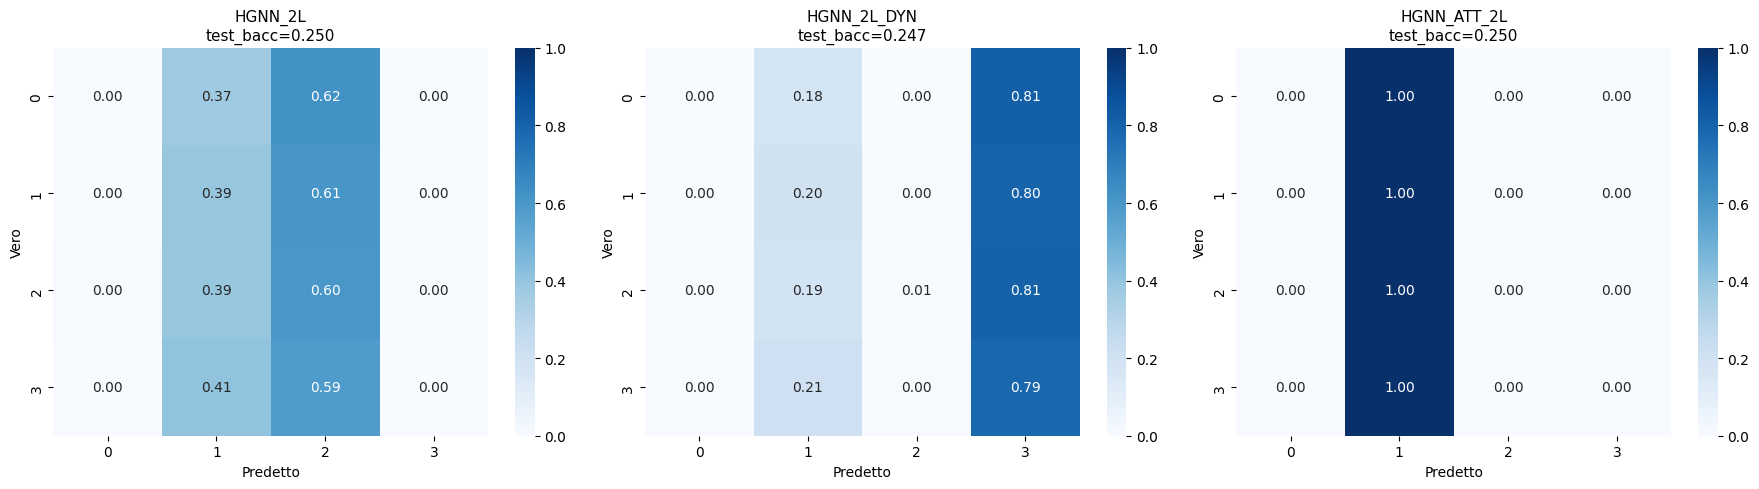

Saved: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg10_confusion_matrices_4cls.png


In [30]:
# ============================================================
# CONFUSION MATRICES (test set, normalizzate per riga)
# ============================================================

fig, axes = plt.subplots(1, len(HGNN_MODELS), figsize=(6 * len(HGNN_MODELS), 5))
if len(HGNN_MODELS) == 1:
    axes = [axes]

for ax, (model_name, cfg) in zip(axes, HGNN_MODELS.items()):
    model_inst = cfg["cls"]()
    ckpt = ckpt_dir / f"{model_name}.pt"
    if ckpt.exists():
        model_inst.load_state_dict(torch.load(ckpt, map_location="cpu"))

    _, test_bacc, ys, ps = evaluate_model(model_inst, ds_test)
    cm = confusion_matrix(ys, ps, normalize="true", labels=list(range(N_CLASSES)))

    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=cluster_names, yticklabels=cluster_names,
                ax=ax, vmin=0, vmax=1)
    ax.set_title(f"{model_name}\ntest_bacc={test_bacc:.3f}", fontsize=11)
    ax.set_xlabel("Predetto")
    ax.set_ylabel("Vero")

plt.tight_layout()
fig_path = project_root / "figures" / f"eeg10_confusion_matrices_{N_CLASSES}cls.png"
fig_path.parent.mkdir(exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")